# Sentiment Analysis Assestment 3
# 1. Download and Extract Source Data

Create the working directory and download the Multi-Domain Sentiment Dataset.
The dataset contains product reviews across four categories: Books, DVD, Electronics, and Kitchen & Housewares.

In [2]:
!mkdir -p /content/raw_data
!wget -q -O /content/domain_sentiment_data.tar.gz https://www.cs.jhu.edu/~mdredze/datasets/sentiment/domain_sentiment_data.tar.gz
!tar -xzf /content/domain_sentiment_data.tar.gz -C /content/raw_data
print("Download complete.")

Download complete.


# 2. Load Reviews into a DataFrame

The source data is in XML format. We use BeautifulSoup to parse each review file and load all four domains into a single DataFrame with three columns: `review_text`, `sentiment` (1 = positive, 0 = negative), and `category`.

In [3]:
import os
import pandas as pd
from bs4 import BeautifulSoup

def parse_review_file(filepath):
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
    soup = BeautifulSoup(f'<root>{content}</root>', 'lxml')
    reviews = []
    for review in soup.find_all('review'):
        text_tag = review.find('review_text')
        if text_tag:
            text = text_tag.get_text(strip=True)
            if text:
                reviews.append(text)
    return reviews

base_path = '/content/raw_data/sorted_data_acl'
domains   = ['books', 'dvd', 'electronics', 'kitchen_&_housewares']

data_list = []
for domain in domains:
    pos_path = os.path.join(base_path, domain, 'positive.review')
    neg_path = os.path.join(base_path, domain, 'negative.review')
    if os.path.exists(pos_path):
        for text in parse_review_file(pos_path):
            data_list.append({'review_text': text, 'sentiment': 1, 'category': domain})
    if os.path.exists(neg_path):
        for text in parse_review_file(neg_path):
            data_list.append({'review_text': text, 'sentiment': 0, 'category': domain})

df_raw = pd.DataFrame(data_list)
df     = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Loaded {len(df):,} total reviews.')
print(f'Columns : {df.columns.tolist()}')
print(f'\nReviews per category:\n{df["category"].value_counts()}')

Loaded 8,000 total reviews.
Columns : ['review_text', 'sentiment', 'category']

Reviews per category:
category
dvd                     2000
books                   2000
electronics             2000
kitchen_&_housewares    2000
Name: count, dtype: int64


# 3. Exploratory Data Analysis (EDA)

Before cleaning, we examine the raw data to understand sentiment balance and review length distribution. This informs our choice of padding length (`max_length=400`) for the LSTM.

Sentiment distribution (raw):
sentiment
1    4000
0    4000
Name: count, dtype: int64

Word Count Statistics (raw):
  Mean : 135.3 words
  Max  : 3393 words


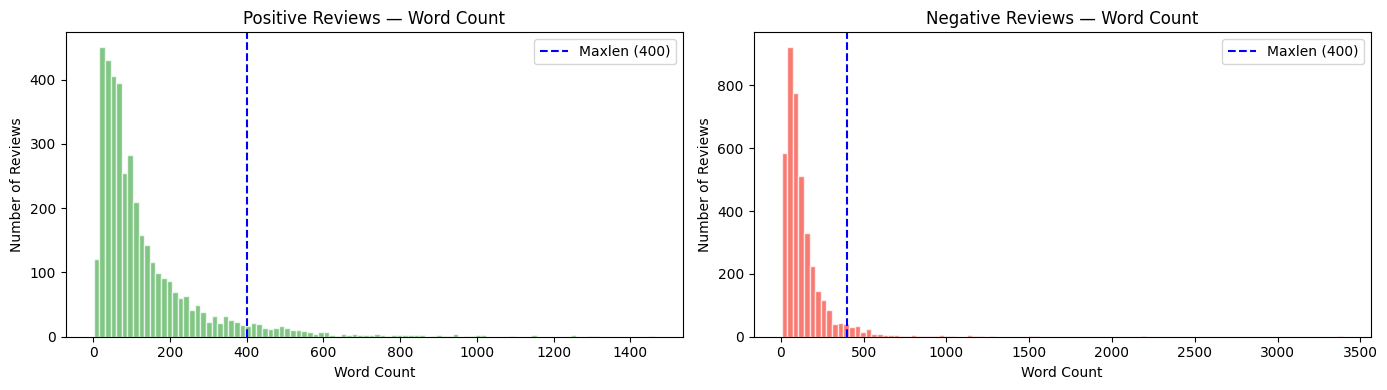

In [4]:
import matplotlib.pyplot as plt

print('Sentiment distribution (raw):')
print(df['sentiment'].value_counts())

df_viz = df.copy()
df_viz['label']      = df_viz['sentiment'].map({1: 'positive', 0: 'negative'})
df_viz['word_count'] = df_viz['review_text'].apply(lambda x: len(str(x).split()))

print(f'\nWord Count Statistics (raw):')
print(f'  Mean : {df_viz["word_count"].mean():.1f} words')
print(f'  Max  : {df_viz["word_count"].max()} words')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, label, color in zip(axes, ['positive', 'negative'], ['#4CAF50', '#f44336']):
    subset = df_viz[df_viz['label'] == label]
    ax.hist(subset['word_count'], bins=100, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{label.capitalize()} Reviews — Word Count')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Number of Reviews')
    ax.axvline(x=400, color='blue', linestyle='--', label='Maxlen (400)')
    ax.legend()
plt.tight_layout()
plt.savefig('/content/eda_word_count.png', dpi=150)
plt.show()

# 4. Word Cloud — Before Cleaning

Visualising the most frequent words before cleaning shows filler words dominate. This justifies the need for stopword removal.

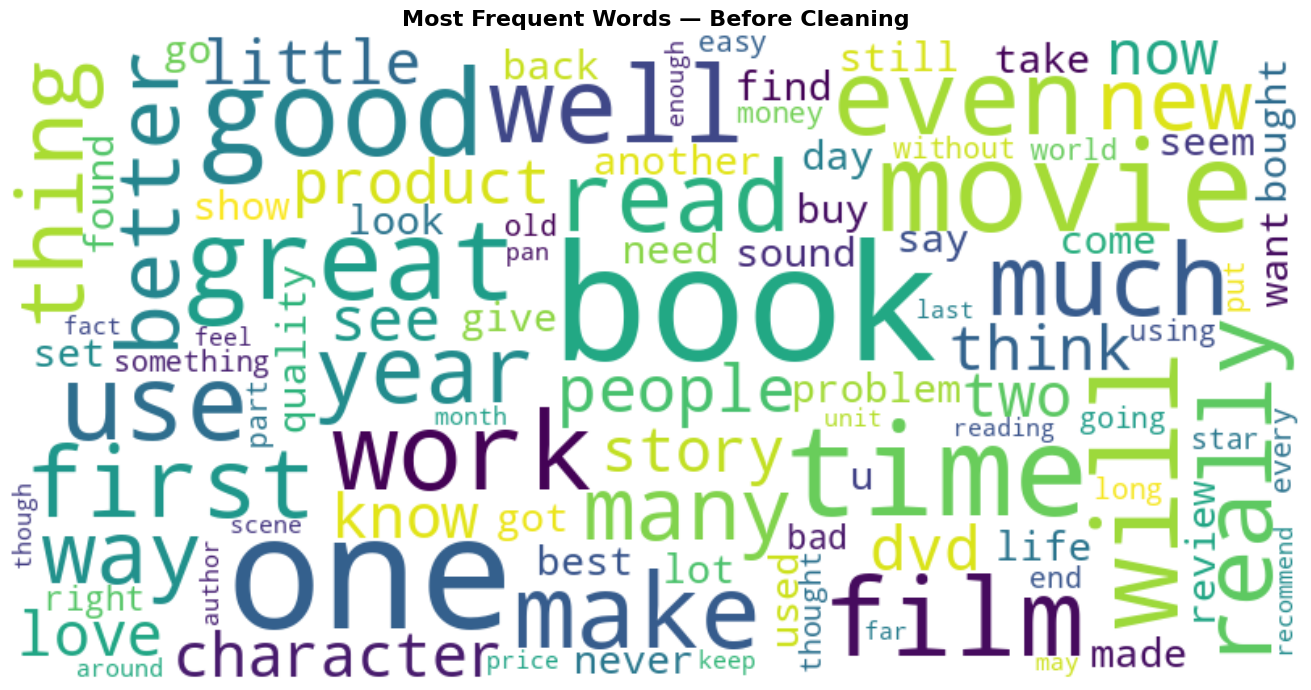

In [5]:
from wordcloud import WordCloud

all_text_raw = ' '.join(df['review_text'].astype(str).tolist()).lower()

wordcloud_before = WordCloud(
    max_font_size=100, max_words=100,
    background_color='white', width=800, height=400, collocations=False
).generate(all_text_raw)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words — Before Cleaning', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/wordcloud_before.png', dpi=150)
plt.show()

# 5. Data Preprocessing

The `clean_text` function applies the following steps to each review:
1. Lowercase
2. Remove non-alphabetic characters
3. Filter stopwords — **keeping negation words** (not, no, never, but, however) to preserve sentiment signals like "not bad"

This lightweight pipeline preserves more vocabulary signal than heavy lemmatization, which benefits LSTM learning.

In [6]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

# Keep negation words so 'not bad' stays 'not bad'
negation_words     = {'not', 'no', 'never', 'neither', 'nor', 'but', 'however'}
filtered_stopwords = stop_words - negation_words

def clean_text(text):
    text  = str(text).lower()
    text  = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    return ' '.join(w for w in words if w not in filtered_stopwords)

# Smoke test
test = "This was not a good product, I won't buy it again."
print(f'Input  : {test}')
print(f'Cleaned: {clean_text(test)}')

Input  : This was not a good product, I won't buy it again.
Cleaned: not good product wont buy


# 6. Apply Cleaning & Verify Samples

Apply `clean_text` to all reviews and display before/after comparisons to confirm the pipeline is working correctly.

In [7]:
print('Cleaning reviews — please wait...')
df['cleaned_review'] = df['review_text'].apply(clean_text)

print('\n--- Cleaning Verification (3 samples) ---')
for i in range(3):
    row = df.iloc[i]
    print(f'ORIGINAL : {row["review_text"][:120]}...')
    print(f'CLEANED  : {row["cleaned_review"][:120]}...')
    print('-' * 50)

Cleaning reviews — please wait...

--- Cleaning Verification (3 samples) ---
ORIGINAL : I cannot recall a time when I did not love this hilarious movie, which is my favourite from the 1980's by far. The super...
CLEANED  : cannot recall time not love hilarious movie favourite far superb bette midler lily tomlin enjoy magical screen chemistry...
--------------------------------------------------
ORIGINAL : I really liked this film.  Before Michael Moore became a liberal celebrity, he was a completely obscure magazine writer ...
CLEANED  : really liked film michael moore became liberal celebrity completely obscure magazine writer filmmaker film major undergr...
--------------------------------------------------
ORIGINAL : Communism is one of the most evil ideologies in human history, responsible for the extermination of 100+ million people....
CLEANED  : communism one evil ideologies human history responsible extermination million people book started holds least much blame...
-----------

# 7. Outlier Removal

Remove duplicate reviews and reviews shorter than 10 words after cleaning. Very short reviews lack enough signal for the model to learn from.

In [8]:
df = df.drop_duplicates(subset=['cleaned_review']).reset_index(drop=True)

df['word_count'] = df['cleaned_review'].apply(lambda x: len(str(x).split()))
df_filtered = df[df['word_count'] >= 10].copy()

print(f'Before outlier removal : {len(df):,} reviews')
print(f'After outlier removal  : {len(df_filtered):,} reviews')

Before outlier removal : 7,851 reviews
After outlier removal  : 7,543 reviews


# 8. Balance and Shuffle the Dataset

Downsample the majority class so the model sees an equal number of positive and negative reviews. This prevents bias toward the more common label — an important ethical consideration in ML.

In [9]:
pos_df = df_filtered[df_filtered['sentiment'] == 1]
neg_df = df_filtered[df_filtered['sentiment'] == 0]

print(f'Before balancing — Positive: {len(pos_df):,}  |  Negative: {len(neg_df):,}')

min_count    = min(len(pos_df), len(neg_df))
pos_balanced = pos_df.sample(n=min_count, random_state=42)
neg_balanced = neg_df.sample(n=min_count, random_state=42)

df_balanced = pd.concat([pos_balanced, neg_balanced])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'After balancing  — Positive: {len(df_balanced[df_balanced["sentiment"]==1]):,}  |  Negative: {len(df_balanced[df_balanced["sentiment"]==0]):,}')
print(f'Total            : {len(df_balanced):,} reviews')

Before balancing — Positive: 3,777  |  Negative: 3,766
After balancing  — Positive: 3,766  |  Negative: 3,766
Total            : 7,532 reviews


# 9. Final Dataset Summary

Display sample reviews from the balanced dataset and visualise label and category distributions.

Final dataset: 7,532 reviews (balanced & shuffled)

--- Sample Reviews ---
  [NEGATIVE] (321 words) review superbit transfer movie dvd movie movie great highly recommend however transfer superbit version lacking several ...

  [POSITIVE] (27 words) based reviews posted purchased board extremely pleased nice big rolling kinds doughs may make room cabinet store dont wa...

  [NEGATIVE] (29 words) avid cook baker used unit twice broke nd useage found slow charge didnt last long keep plugged dough soft order press pr...



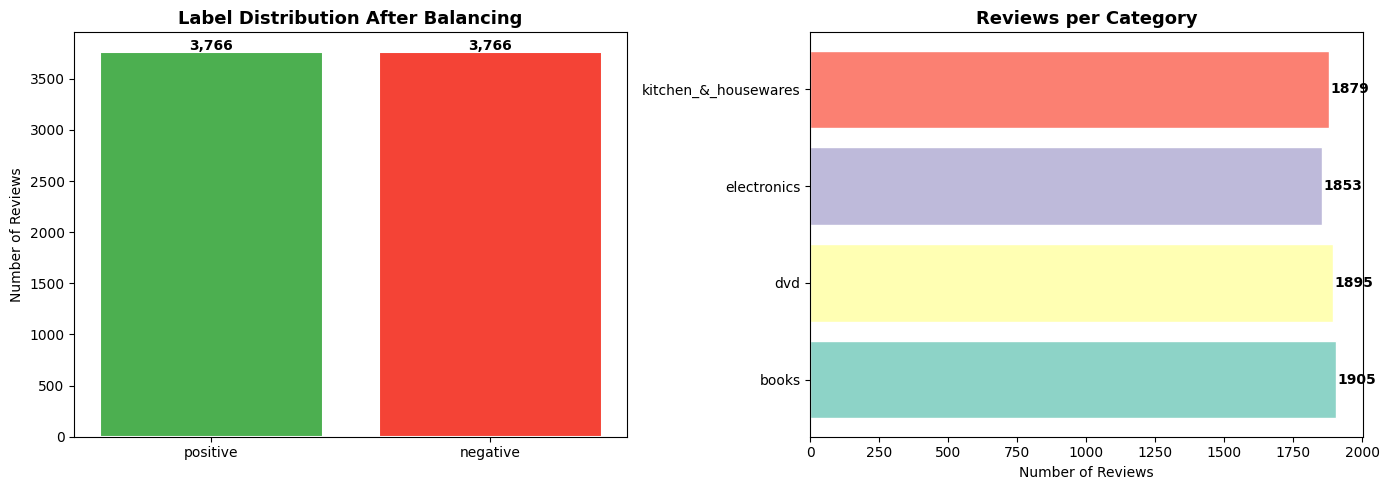

In [10]:
from collections import Counter

df_balanced['word_count'] = df_balanced['cleaned_review'].apply(lambda x: len(str(x).split()))

print(f'Final dataset: {len(df_balanced):,} reviews (balanced & shuffled)')
print('\n--- Sample Reviews ---')
for _, row in df_balanced.sample(3, random_state=1).iterrows():
    label = 'POSITIVE' if row['sentiment'] == 1 else 'NEGATIVE'
    print(f'  [{label}] ({row["word_count"]} words) {row["cleaned_review"][:120]}...')
    print()

label_counts    = Counter(df_balanced['sentiment'].map({1: 'positive', 0: 'negative'}))
category_counts = Counter(df_balanced['category'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

keys   = ['positive', 'negative']
values = [label_counts[k] for k in keys]
axes[0].bar(keys, values, color=['#4CAF50', '#f44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Label Distribution After Balancing', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

cat_names  = sorted(category_counts.keys())
cat_values = [category_counts[c] for c in cat_names]
axes[1].barh(cat_names, cat_values, color=plt.cm.Set3.colors, edgecolor='white')
axes[1].set_title('Reviews per Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Reviews')
for i, v in enumerate(cat_values):
    axes[1].text(v + 5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/final_stats.png', dpi=150)
plt.show()

# 10. Word Cloud — Before vs After Cleaning

Comparing both clouds confirms filler words have been removed and meaningful sentiment words now dominate.

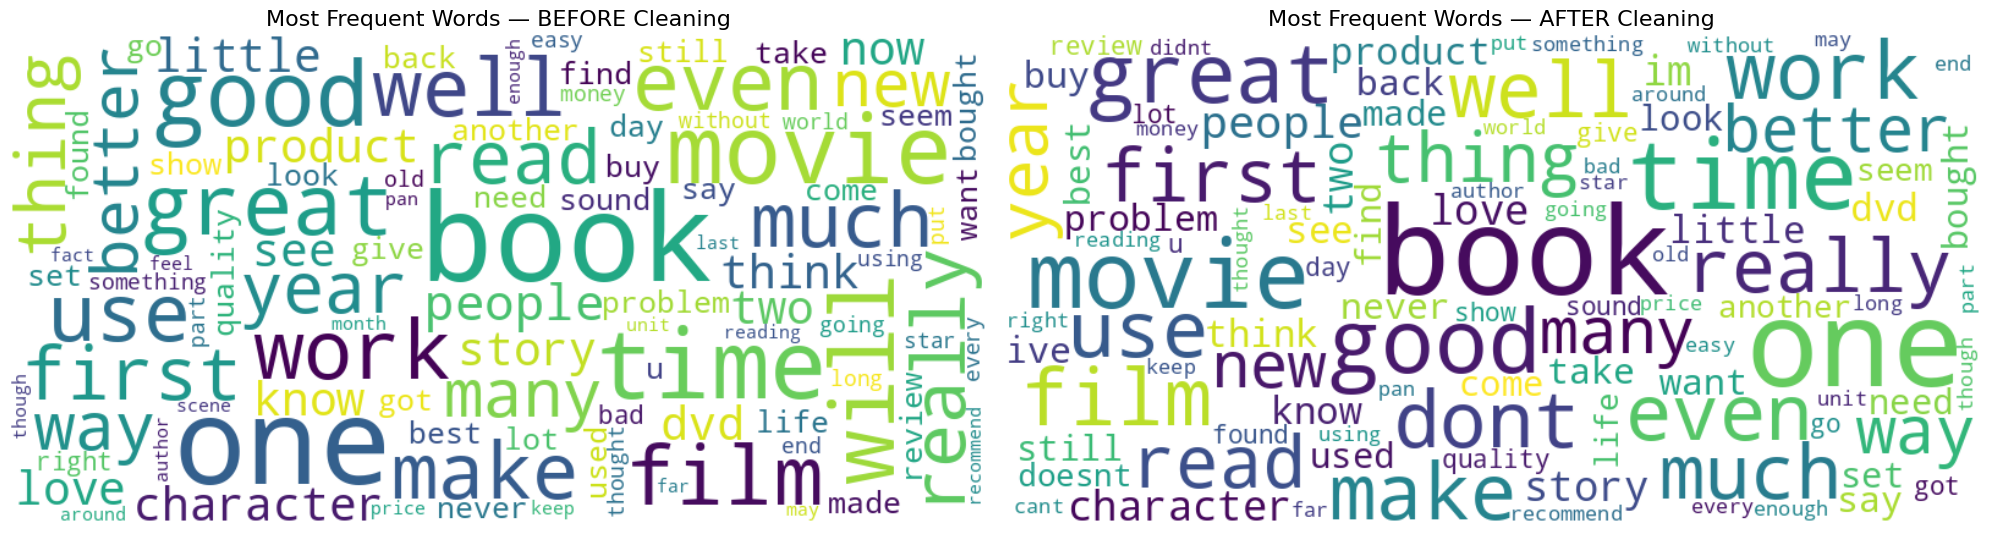

In [11]:
all_text_cleaned = ' '.join(df_balanced['cleaned_review'].tolist())

wordcloud_after = WordCloud(
    max_font_size=100, max_words=100,
    background_color='white', width=800, height=400, collocations=False
).generate(all_text_cleaned)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(wordcloud_before, interpolation='bilinear')
axes[0].set_title('Most Frequent Words — BEFORE Cleaning', fontsize=16)
axes[0].axis('off')
axes[1].imshow(wordcloud_after, interpolation='bilinear')
axes[1].set_title('Most Frequent Words — AFTER Cleaning', fontsize=16)
axes[1].axis('off')
plt.tight_layout()
plt.savefig('/content/wordcloud_comparison.png', dpi=150)
plt.show()

# 11. Vocabulary Size Check

Check the total vocabulary size and average review length. These values confirm our tokenizer settings (`vocab_size=10000`, `max_length=400`) are well-suited to this dataset.

In [12]:
all_words    = ' '.join(df_balanced['cleaned_review']).split()
unique_words = len(set(all_words))
avg_len      = df_balanced['word_count'].mean()
max_len      = df_balanced['word_count'].max()

print(f'Total unique words   : {unique_words:,}')
print(f'Average review length: {avg_len:.1f} words')
print(f'Max review length    : {max_len} words')

Total unique words   : 44,304
Average review length: 73.5 words
Max review length    : 1860 words


# 12. Keras Tokenizer and Padding

The cleaned text is tokenised using the Keras `Tokenizer`, which maps each word to an integer index.

Bigrams (adjacent word pairs like `not_good`) are appended before tokenisation. This gives the model short-range context — the pair `not_bad` carries different meaning than `not` and `bad` separately.

Sequences are padded or truncated to a fixed length so all inputs to the LSTM have the same shape.

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Hyperparameters
VOCAB_SIZE = 10000
MAX_LENGTH = 400
OOV_TOKEN  = '<OOV>'

def create_bigrams(text):
    words   = str(text).split()
    bigrams = ['_'.join(words[i:i+2]) for i in range(len(words) - 1)]
    return text + ' ' + ' '.join(bigrams)

# Apply bigrams to the balanced dataset
df_balanced['ngram_text'] = df_balanced['cleaned_review'].apply(create_bigrams)

# Fit tokenizer on the full balanced corpus
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df_balanced['ngram_text'])

# Convert to padded integer sequences
sequences = tokenizer.texts_to_sequences(df_balanced['ngram_text'])
X_padded  = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
y         = np.array(df_balanced['sentiment'].values)

print(f'X_padded shape : {X_padded.shape}  (reviews x tokens)')
print(f'y shape        : {y.shape}')

X_padded shape : (7532, 400)  (reviews x tokens)
y shape        : (7532,)


# 13. Train / Test Split

Split into 80% training and 20% test sets. `random_state=42` ensures reproducibility.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')

Training samples : 6,025
Test samples     : 1,507


# 14. Build and Train the LSTM Model

The model architecture:

- **Embedding** — learns a 100-dimensional dense vector for each token
- **SpatialDropout1D** — regularises the embedding layer by dropping entire feature dimensions
- **Bidirectional LSTM** — reads the sequence forwards and backwards to capture long-range sentiment context
- **GlobalMaxPooling1D** — picks the most salient feature across all time steps
- **Dense (ReLU) + Dropout** — non-linear classification head with regularisation
- **Dense (Sigmoid)** — outputs a probability: 0 = negative, 1 = positive

`EarlyStopping` halts training when validation loss stops improving and automatically restores the best weights.

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SpatialDropout1D, Bidirectional, LSTM,
    GlobalMaxPooling1D, Dense, Dropout
)

model = Sequential([
    Embedding(VOCAB_SIZE, 100),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='Sentiment_LSTM')

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

print('\nTraining...')
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Model: "Sentiment_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training...
Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.6493 - loss: 0.6071 - val_accuracy: 0.7525 - val_loss: 0.4978
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8586 - loss: 0.3419 - val_accuracy: 0.8003 - val_loss: 0.4385
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9396 - loss: 0.1776 - val_accuracy: 0.7916 - val_loss: 0.5456
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.9638 - loss: 0.1017 - val_accuracy: 0.7764 - val_loss: 0.7577
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9834 - loss: 0.0579 - val_accuracy: 0.7770 - val_loss: 0.8766


# 15. Visualise Training Results

Plot accuracy and loss curves for both training and validation sets. Ideally both curves trend together — a large gap between them indicates overfitting.

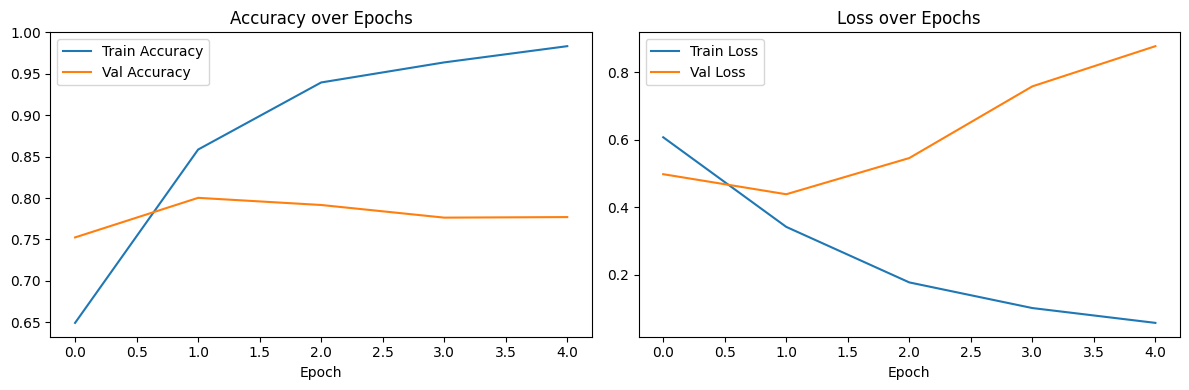

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

# 16. Predict Sentiment

A helper function that runs a single review through the exact same pipeline used during training: `clean_text` → `create_bigrams` → tokenize → pad → predict.

In [17]:
def predict_sentiment(text):
    cleaned    = clean_text(text)
    ngram      = create_bigrams(cleaned)
    seq        = tokenizer.texts_to_sequences([ngram])
    padded     = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    prediction = model.predict(padded, verbose=0)[0][0]

    sentiment  = 'Positive' if prediction > 0.5 else 'Negative'
    confidence = prediction if sentiment == 'Positive' else 1 - prediction
    return f'Sentiment: {sentiment} ({confidence*100:.2f}% confidence)'

print(predict_sentiment('This was a fantastic purchase, I am so happy with how it works!'))
print(predict_sentiment('Waste of money. It broke after two days and the support was terrible.'))
print(predict_sentiment('Not bad at all, actually quite good.'))

Sentiment: Positive (97.19% confidence)
Sentiment: Negative (99.47% confidence)
Sentiment: Negative (80.91% confidence)


# 17. Interactive Sentiment Bot

Type a review to get a live prediction. Type `exit` or `quit` to stop.

In [18]:
def interactive_sentiment_bot():
    print('─' * 40)
    print('  Sentiment Analysis Bot')
    print('  Type a review to get a prediction.')
    print('  Type exit or quit to stop.')
    print('─' * 40)

    while True:
        user_input = input('\nEnter a review: ').strip()

        if not user_input:
            continue
        if user_input.lower() in ['exit', 'quit']:
            print('Goodbye!')
            break

        cleaned    = clean_text(user_input)
        ngram      = create_bigrams(cleaned)
        seq        = tokenizer.texts_to_sequences([ngram])
        padded     = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
        prediction = model.predict(padded, verbose=0)[0][0]
        sentiment  = 'POSITIVE' if prediction > 0.5 else 'NEGATIVE'
        confidence = prediction if sentiment == 'POSITIVE' else 1 - prediction

        filled = int(confidence * 20)
        bar    = chr(9608) * filled + '-' * (20 - filled)
        print(f'[{bar}]')
        print(f'Result : {sentiment} ({confidence*100:.2f}% confidence)')
        print('─' * 40)

interactive_sentiment_bot()

────────────────────────────────────────
  Sentiment Analysis Bot
  Type a review to get a prediction.
  Type exit or quit to stop.
────────────────────────────────────────
[███████████████-----]
Result : POSITIVE (79.45% confidence)
────────────────────────────────────────
[█████████████-------]
Result : POSITIVE (66.76% confidence)
────────────────────────────────────────
[██████████████------]
Result : POSITIVE (72.82% confidence)
────────────────────────────────────────
[███████████---------]
Result : POSITIVE (56.98% confidence)
────────────────────────────────────────
[██████████----------]
Result : NEGATIVE (50.09% confidence)
────────────────────────────────────────
[█████████████████---]
Result : NEGATIVE (87.77% confidence)
────────────────────────────────────────
[██████████----------]
Result : POSITIVE (51.79% confidence)
────────────────────────────────────────


KeyboardInterrupt: Interrupted by user

# 18. Save the Model

Save the trained model in Keras format so it can be reloaded without retraining.

In [19]:
model.save('my_sentiment_model.keras')
print("Model saved to 'my_sentiment_model.keras'")

Model saved to 'my_sentiment_model.keras'


# 19. Benchmark Against BERT (DistilBERT)

Compare our custom LSTM against DistilBERT, a pre-trained transformer from Google fine-tuned on millions of examples. This provides a near-state-of-the-art quality benchmark for sentiment classification.

In [20]:
from transformers import pipeline

classifier = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english'
)

def bert_predict(review):
    result = classifier(review)[0]
    label  = result['label']
    score  = result['score']
    bar    = chr(9608) * int(score * 20) + '-' * (20 - int(score * 20))
    print(f'Review : {review}')
    print(f'[{bar}]')
    print(f'Result : {label} ({score*100:.2f}% confidence)')
    print('-' * 40)

bert_predict('this book was good')
bert_predict('the dvd was not bad')
bert_predict('not good at all')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Review : this book was good
[███████████████████-]
Result : POSITIVE (99.99% confidence)
----------------------------------------
Review : the dvd was not bad
[███████████████████-]
Result : POSITIVE (99.82% confidence)
----------------------------------------
Review : not good at all
[███████████████████-]
Result : NEGATIVE (99.98% confidence)
----------------------------------------
